# Milestone 4 — NSGA-II Multi-Objective Evolution & MAP-Elites

Objectives:
- **Maximise** locomotion distance (NormFinalDist from voxelyze)
- **Minimise** voxel count (body efficiency)

Extension: MAP-Elites illumination over (distance, symmetry) behaviour space.

In [2]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import os, sys, json
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Find project root regardless of where Jupyter was launched from
def _find_root():
    for candidate in [os.path.abspath('.'), os.path.abspath('..')]:
        if os.path.exists(os.path.join(candidate, 'src')):
            return candidate
    raise RuntimeError('Cannot find project root — no src/ directory found')

ROOT = _find_root()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Off-screen rendering for PyVista
pv.OFF_SCREEN = True

# Set voxelyze binary env var
os.environ.setdefault('VOXCRAFT_BIN', os.path.join(ROOT, 'voxelyze'))

print(f'ROOT: {ROOT}')
print('Setup complete')

ROOT: /Users/hiremath/Documents/Projects_AI/xenobot_evolution
Setup complete


In [8]:
# ── Load M3 results ───────────────────────────────────────────────────────────
# M3 results land in notebooks/results/m3/ when run from the notebook
M3_DIR = 'results/m3'

best_genome  = np.load(os.path.join(M3_DIR, 'best_genome.npy'))
hof_genomes  = np.load(os.path.join(M3_DIR, 'hof_genomes.npy'))

with open(os.path.join(M3_DIR, 'full_run_log.json')) as f:
    m3_log = json.load(f)

m3_fitnesses  = [rec['max'] for rec in m3_log]
hof_fitnesses = [m3_fitnesses[-1]] * len(hof_genomes)  # approximate

print(f'Loaded best genome shape: {best_genome.shape}')
print(f'HoF genomes: {len(hof_genomes)}')

Loaded best genome shape: (8, 8, 8)
HoF genomes: 10


In [3]:
# ── NSGA-II quick test (pop=10, gen=5) ────────────────────────────────────────
from src.multiobjective import run_nsga2

pop_test, log_test, hof_test = run_nsga2(config={
    'pop_size':      10,
    'n_generations': 5,
    'mu':            10,
    'lambda_':       20,
    'n_workers':     2,
    'save_dir':      'results/m4/quick_test/',
})
print(f'Quick test — pop size: {len(pop_test)}, log entries: {len(log_test)}')

Gen   0 | HV: 1297.1493 | Pareto size:   2 | Max dist: 9.4764
Quick test — pop size: 10, log entries: 6


## Full NSGA-II Run

**Runtime estimate:** ~80 generations × 40 pop × ~2 s/eval / 4 workers ≈ **1–2 hours on Mac CPU.**

Run with `nohup` or overnight:
```bash
nohup python -m src.multiobjective > results/m4/nsga2_run.log 2>&1 &
```

In [4]:
# ── Full NSGA-II run ──────────────────────────────────────────────────────────
import yaml

with open(os.path.join(ROOT, 'configs', 'nsga2.yaml')) as f:
    nsga2_cfg = yaml.safe_load(f)

pop, log, hof = run_nsga2(config=nsga2_cfg)
print(f'NSGA-II complete. Final pop size: {len(pop)}, HoF size: {len(hof)}')

Gen   0 | HV: 1962.8307 | Pareto size:   2 | Max dist: 13.5969
Gen  10 | HV: 7050.5955 | Pareto size:   3 | Max dist: 38.4238
Gen  20 | HV: 11206.3694 | Pareto size:  15 | Max dist: 56.1095
Gen  30 | HV: 15110.4789 | Pareto size:  13 | Max dist: 68.8370
Gen  40 | HV: 15845.2501 | Pareto size:  15 | Max dist: 70.3933
Gen  50 | HV: 18405.3316 | Pareto size:   5 | Max dist: 75.9096
Gen  60 | HV: 23867.7935 | Pareto size:   8 | Max dist: 93.7552
Gen  70 | HV: 25545.4478 | Pareto size:  40 | Max dist: 97.6017
Gen  80 | HV: 28819.8938 | Pareto size:  31 | Max dist: 107.3530
NSGA-II complete. Final pop size: 40, HoF size: 20


In [5]:
# ── Load NSGA-II results (if run externally) ──────────────────────────────────
M4_DIR = 'results/m4'

with open(os.path.join(M4_DIR, 'nsga2_log.json')) as f:
    log = json.load(f)

# # Reconstruct population with fitness for plotting
# from src.multiobjective import build_toolbox_mo, creator
# from deap import creator as dc

# pop_arr  = np.load(os.path.join(M4_DIR, 'nsga2_final_pop.npy'), allow_pickle=True)
# hof_arr  = np.load(os.path.join(M4_DIR, 'nsga2_hof.npy'),       allow_pickle=True)

# # Re-evaluate to restore fitness values
# from src.multiobjective import evaluate_mo
# pop = []
# for genome in pop_arr:
#     ind = dc.IndividualMO(np.asarray(genome, dtype=int))
#     ind.fitness.values = evaluate_mo(np.asarray(genome, dtype=int))
#     pop.append(ind)

print(f'Loaded {len(pop)} individuals, {len(log)} log records')

Loaded 4 individuals, 81 log records


Saved pareto front plot → results/m4/pareto_front.png


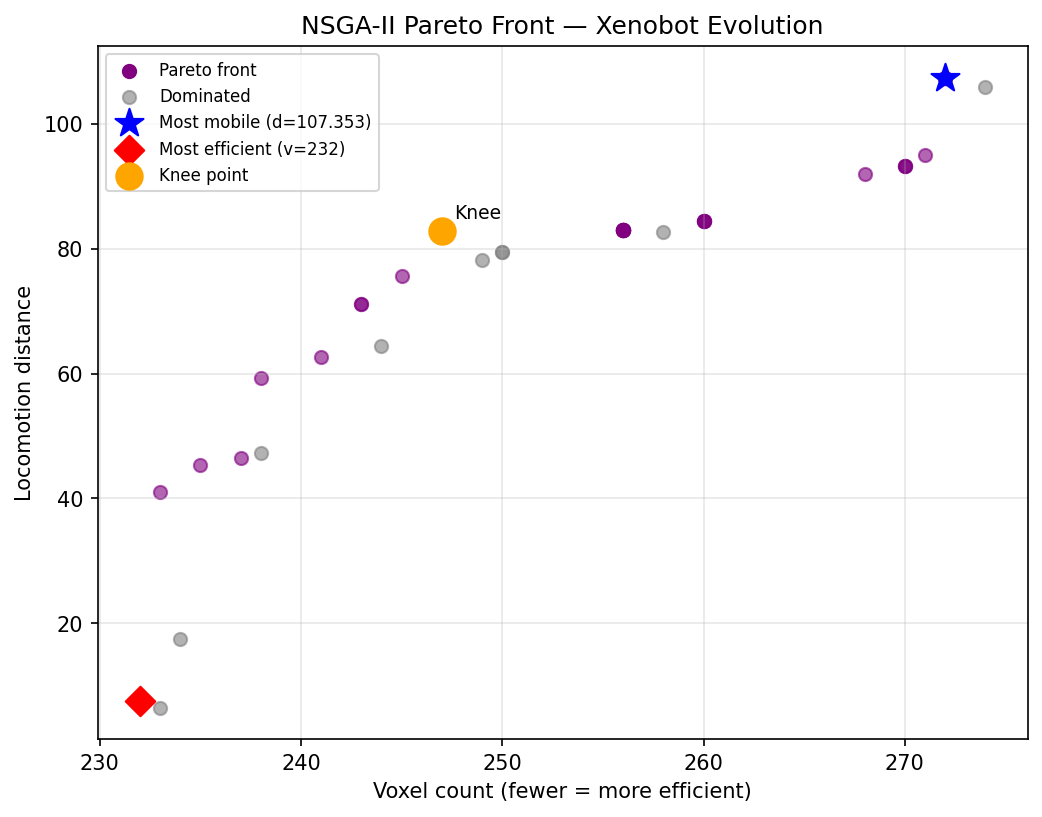

In [9]:
# ── Pareto front plot ─────────────────────────────────────────────────────────
from src.milestone4.pareto_analysis import plot_pareto_front

plot_pareto_front(pop, save_path='results/m4/pareto_front.png')
display(Image('results/m4/pareto_front.png'))

In [10]:
# ── Render Pareto extremes ────────────────────────────────────────────────────
from src.milestone4.pareto_analysis import render_pareto_extremes

render_pareto_extremes(pop, save_dir='renders/m4/')

Saved renders/m4/most_mobile.png
Saved renders/m4/most_efficient.png
Saved renders/m4/knee_point.png


most_mobile


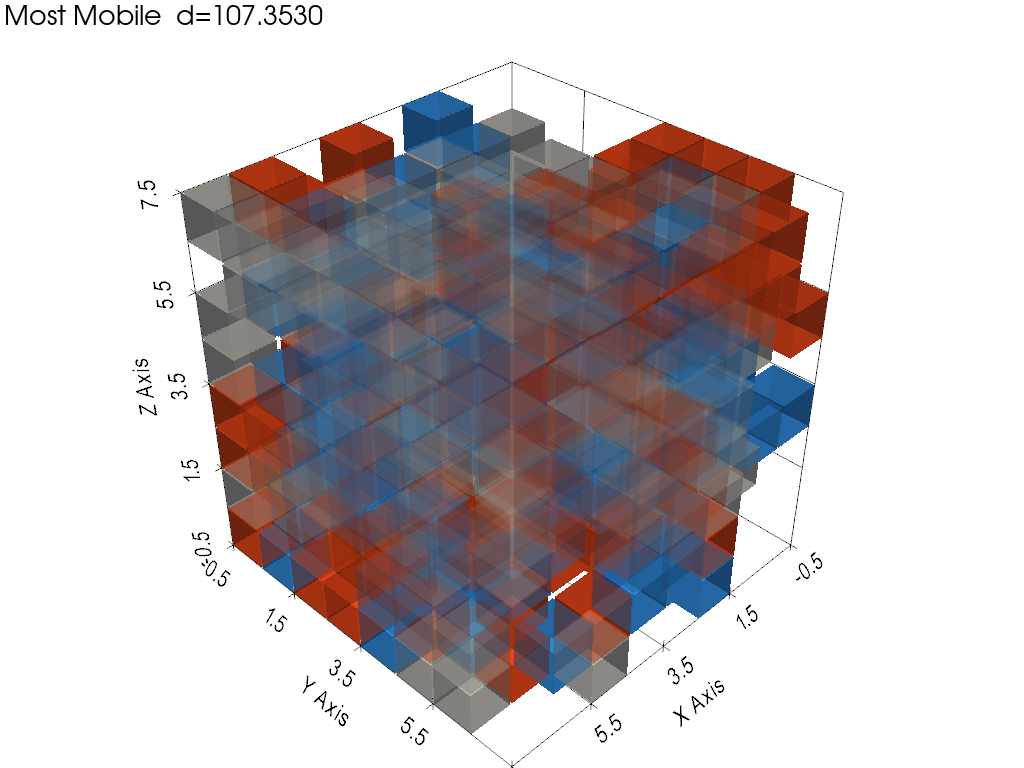

most_efficient


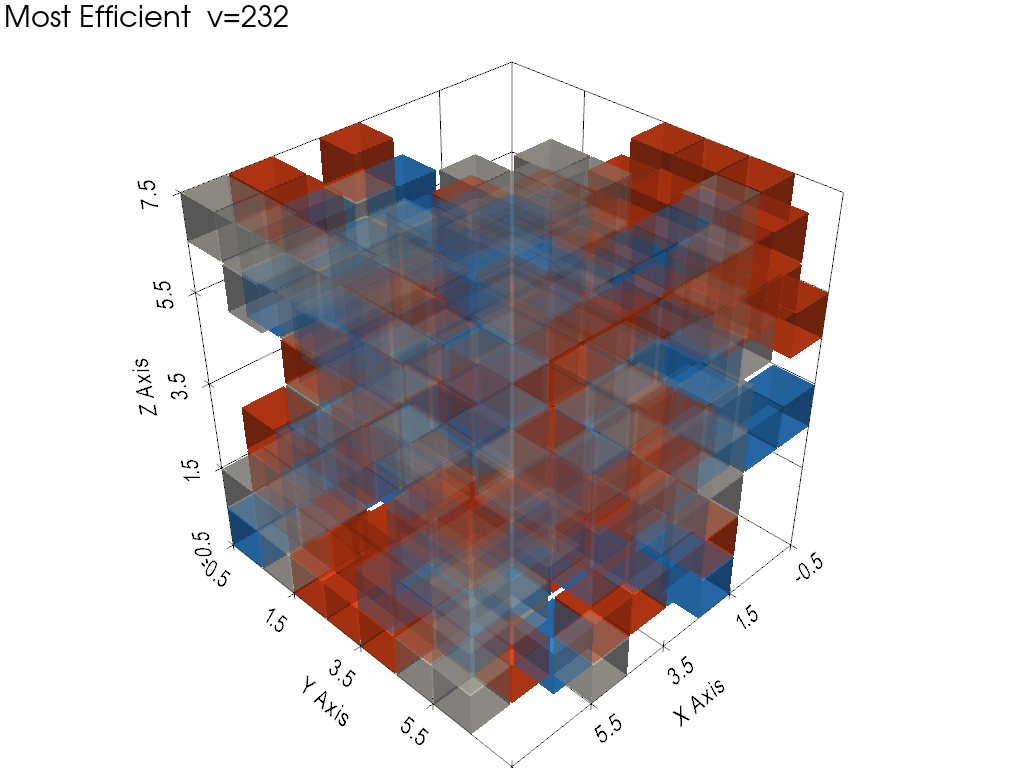

knee_point


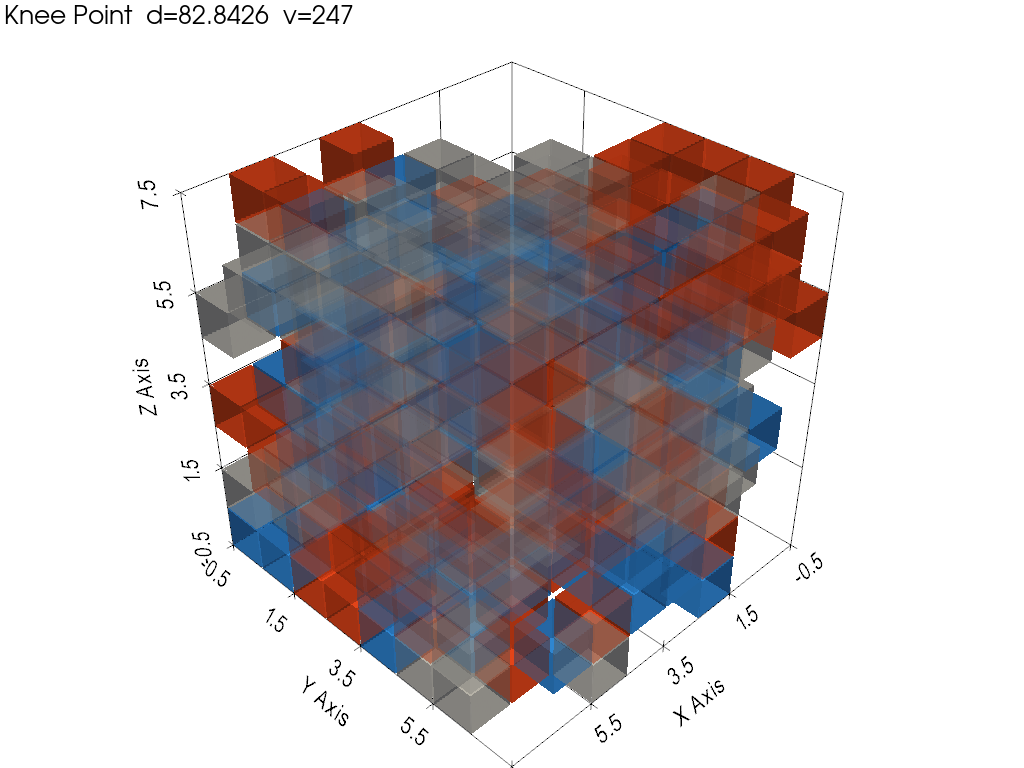

In [11]:
# ── Display renders inline ────────────────────────────────────────────────────
for name in ('most_mobile', 'most_efficient', 'knee_point'):
    path = f'renders/m4/{name}.png'
    if os.path.exists(path):
        print(name)
        display(Image(path))

Saved hypervolume comparison → results/m4/hypervolume_comparison.png


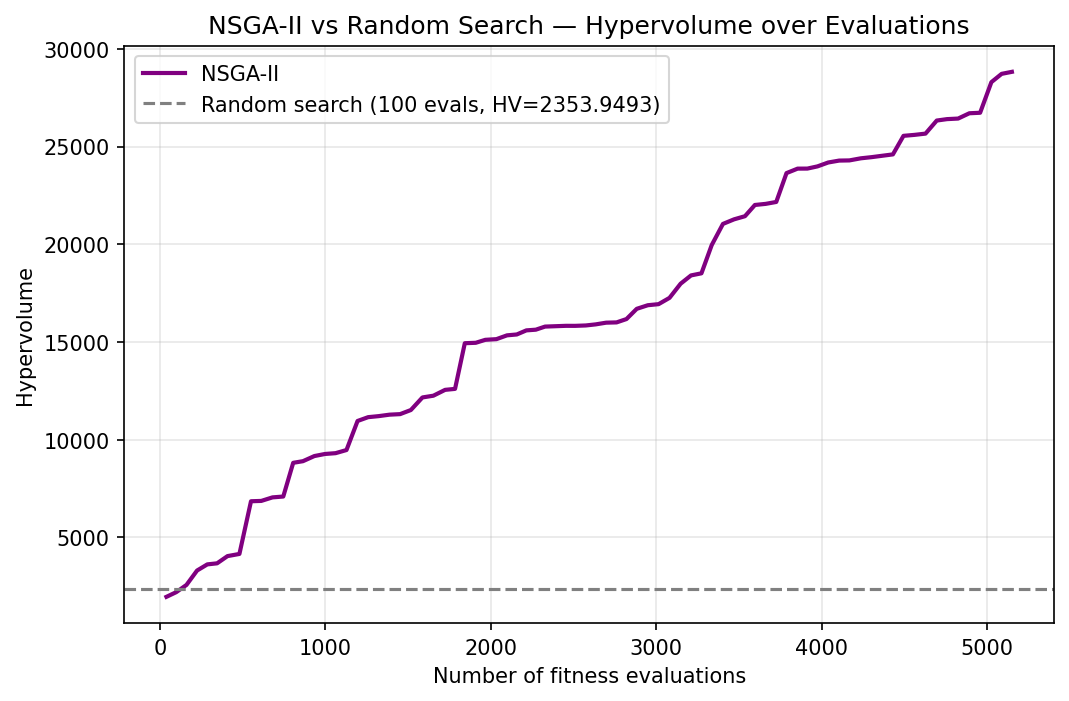

In [6]:
# ── Hypervolume comparison ────────────────────────────────────────────────────
from src.milestone4.pareto_analysis import compare_hypervolume

# Cap baseline at 100 — random_search_baseline runs voxelyze sequentially,
# so passing n_evals (~6k) from the log would take ~3.5 hours on M1.
compare_hypervolume(log, n_evaluations=100, save_path='results/m4/hypervolume_comparison.png')
display(Image('results/m4/hypervolume_comparison.png'))

In [9]:
# ── Morphological analysis ────────────────────────────────────────────────────
from src.milestone4.morphological_analysis import analyse_top_robots

analyse_top_robots(
    hof_genomes,
    hof_fitnesses,
    save_dir='results/m4/',
)

Saved morphological analysis to results/m4/


active_ratio_vs_fitness


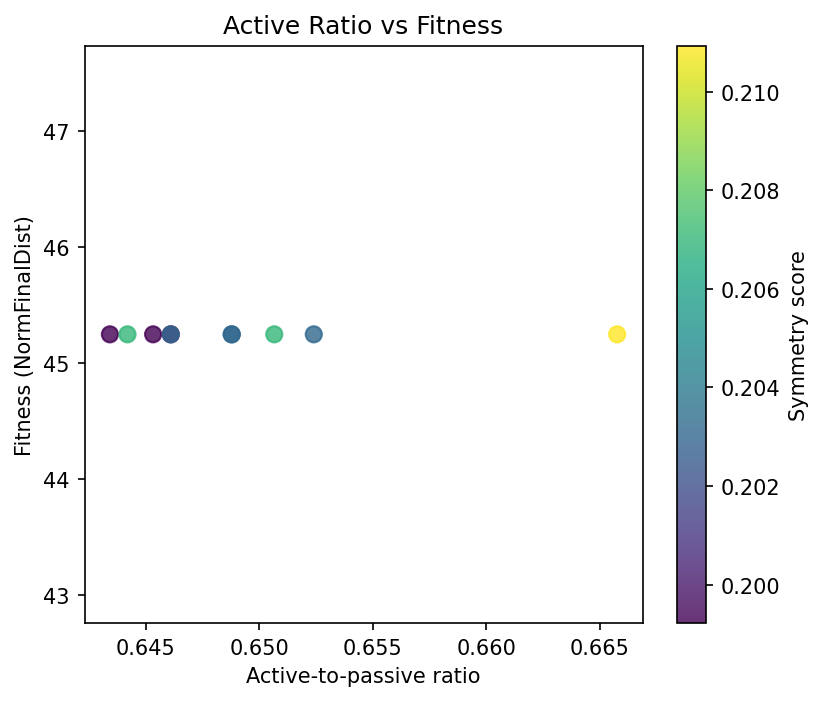

com_height_vs_fitness


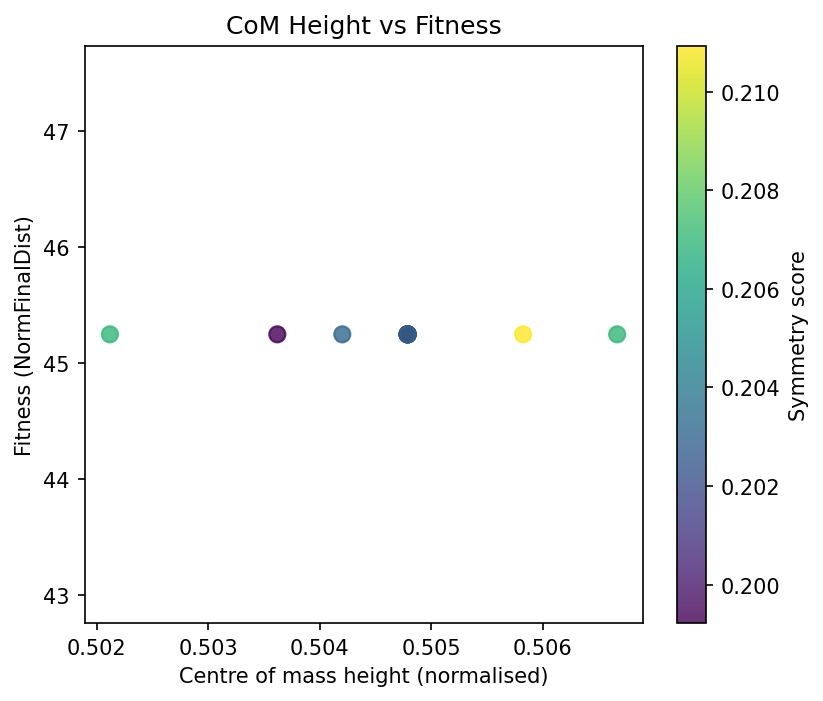

symmetry_vs_fitness


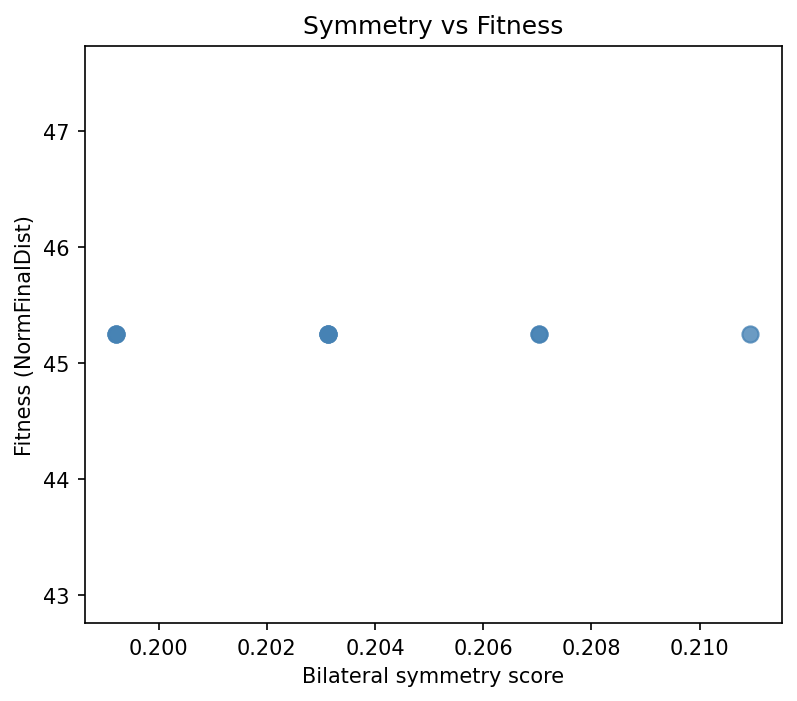

In [10]:
# ── Display morphology plots inline ──────────────────────────────────────────
for name in ('active_ratio_vs_fitness', 'com_height_vs_fitness', 'symmetry_vs_fitness'):
    path = f'results/m4/{name}.png'
    if os.path.exists(path):
        print(name)
        display(Image(path))

In [ ]:
# ── MAP-Elites run ────────────────────────────────────────────────────────────
from src.milestone4.map_elites import run_map_elites

# Runtime: random genomes are ~384 voxels (75% fill) → ~15s/eval on M1.
# 50 iters × 5 batch = 255 evals / 4 workers ≈ 16 min at sim_time=1.0
#                                              ≈  8 min at sim_time=0.5
# Full run (500 iters × 10 batch = 5005 evals / 4 workers) ≈ 3–6 h overnight.
grid, me_log = run_map_elites(config={
    'n_iterations': 50,
    'batch_size':   5,
    'n_workers':    4,
    'sim_time':     0.5,   # faster demo; use 1.0 for final results
    'save_dir':     'results/m4/map_elites/',
})
print(f'MAP-Elites done. Cells filled: {len(grid)} / 100')

In [ ]:
# ── MAP-Elites grid plot ──────────────────────────────────────────────────────
from src.milestone4.map_elites import plot_map_elites_grid

plot_map_elites_grid(grid, save_path='results/m4/map_elites/grid_heatmap.png')
display(Image('results/m4/map_elites/grid_heatmap.png'))

In [ ]:
# ── MAP-Elites vs NSGA-II comparison ─────────────────────────────────────────
from src.milestone4.map_elites import compare_map_elites_vs_nsga2

compare_map_elites_vs_nsga2(grid, pop, save_path='results/m4/me_vs_nsga2.png')
display(Image('results/m4/me_vs_nsga2.png'))

## Morphological Computation Evidence (300 words)

Based on the morphological analysis above:

- **Active-to-passive ratio finding:**  
  _(Fill in after running analysis — e.g., higher active ratio correlates with X fitness range)_

- **Centre of mass height finding:**  
  _(Fill in — e.g., robots with lower CoM tend to have higher fitness / greater stability)_

- **Structural motifs observed:**  
  _(Fill in — e.g., the most frequent motif is a 2×2×2 alternating active block)_

- **Conclusion re: morphological computation:**  
  _(Fill in — does body shape contribute to locomotion beyond just material type?)_